# Radar Object Classification Using Range-Doppler Maps

This notebook implements a radar-based object classification pipeline using cropped **Range-Doppler (RD) maps** together with additional radar features.

The pipeline includes:

* Radar data loading from `.pkl` files
* Range-Doppler map visualization
* Class-based data organization
* Class balancing
* Feature normalization
* PyTorch CNN-based classification
* Fusion of RD-map and radar metadata
* Model training and validation
* Permutation-based feature importance
* Confusion matrix evaluation
* Multiclass ROC/AUC evaluation
* A Keras implementation with 5-fold cross-validation
* ONNX model export
* ONNX Runtime inference
> **Dataset note:** The original radar measurements are not included in this repository. The user must provide the corresponding `.pkl` files.


In [1]:
# Optional: switch Windows to a high-performance power plan.
# The command is specific to Windows.

!powercfg /setactive 8c5e7fda-e8bf-4a96-9a85-a6e23a8c635c

In [2]:
from pathlib import Path

import pandas as pd

# Directory containing the radar .pkl files.
DATA_DIR = Path(".")

# Load the three radar datasets.
radar_51 = pd.read_pickle(DATA_DIR / "radar_east_ip51.pkl")
radar_52 = pd.read_pickle(DATA_DIR / "radar_west_ip52.pkl")
radar_53 = pd.read_pickle(DATA_DIR / "radar_videtec_ip53.pkl")

print(f"Radar 51 samples: {len(radar_51):,}")
print(f"Radar 52 samples: {len(radar_52):,}")
print(f"Radar 53 samples: {len(radar_53):,}")

Radar 51 samples: 18,155
Radar 52 samples: 37,360
Radar 53 samples: 49,679


In [3]:
import torch

# This notebook is configured to use the CPU.
device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Using device: {device}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.14.0+cpu
Using device: cpu
CUDA available: False


# Dataset Description

Each radar detection is stored as a list containing the following elements:

| Index | Description                                             |
| ----: | ------------------------------------------------------- |
|     0 | Cropped Range-Doppler map, represented as a NumPy array |
|     1 | Sample number                                           |
|     2 | Range bin                                               |
|     3 | Doppler bin                                             |
|     4 | Detection magnitude                                     |
|     5 | Azimuth angle                                           |
|     6 | Elevation angle                                         |
|     7 | Timestamp                                               |
|     8 | Object label                                            |
|     9 | Measurement run name                                    |

The cropped RD map has a size of **31 × 41**.

### Object labels

| Label | Object           |
| ----: | ---------------- |
|     2 | Pedestrian       |
|     3 | Cyclist          |
|     4 | Car              |
|     5 | Truck            |
|     7 | Van *(not used)* |
|    12 | Scooter          |

Radar 51 and Radar 52 contain four classes, while Radar 53 additionally contains the scooter class.

### Measurement protocol

The original measurement protocol is part of the internal measurement campaign and is therefore **not included as a public link in this notebook**.

If you have access to the original measurement protocol, refer to the corresponding measurement folders for runs 51, 52, and 53.


In [4]:
# Display the first sample from Radar 53.
radar_53[0]

[[array([[5583, 5494, 5289, ..., 5161, 5021, 5323],
         [5485, 5469, 5413, ..., 5148, 5237, 5314],
         [5439, 5409, 5412, ..., 5271, 5405, 5408],
         ...,
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0]],
        shape=(31, 41), dtype=uint16)],
 [np.int64(300)],
 [121],
 [-29],
 [25],
 [-16],
 [7],
 np.int64(1719486450396),
 [np.float64(4.0)],
 ['run7']]

# Range-Doppler Map Visualization

The following plot shows the expected representation of a cropped Range-Doppler map.

When using a different radar dataset, the generated RD map should follow the same format:

* Shape: **31 × 41**
* Vertical axis: Range
* Horizontal axis: Doppler
* Pixel/value intensity: Detection magnitude


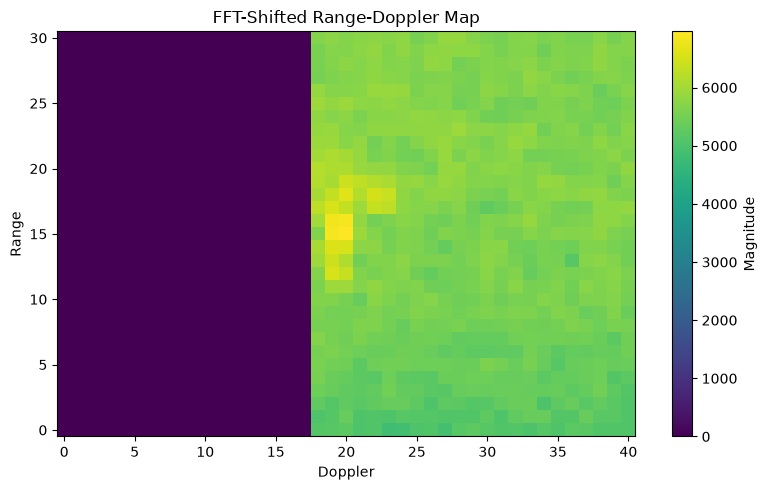

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.imshow(
    radar_52[0][0][0],
    aspect="auto",
    cmap="viridis",
    origin="lower",
)

plt.colorbar(label="Magnitude")
plt.title("FFT-Shifted Range-Doppler Map")
plt.xlabel("Doppler")
plt.ylabel("Range")

plt.tight_layout()
plt.show()

# Data Preparation

For this experiment, Radar 53 is used as the training dataset.

The preprocessing pipeline consists of:

1. Selecting the desired radar dataset.
2. Excluding specific measurement runs when required.
3. Separating samples according to object class.
4. Balancing the number of samples per class.
5. Shuffling the data.
6. Extracting the RD maps and radar metadata.
7. Converting range bins into physical distance.
8. Standardizing the input features.
9. Reshaping the data for PyTorch and Keras.


In [7]:
# Radar 53 is used for this experiment because it contains five classes.
train_data = radar_53

In [8]:
# Lists containing samples for each object class.
all_car_data = []
all_cyc_data = []
all_ped_data = []
all_scooter_data = []
all_truck_data = []

# Label and run positions within each radar sample.
LABEL_INDEX = -2
RUN_INDEX = -1

for sample in train_data:

    # Extract the measurement run name.
    run_name = sample[RUN_INDEX][0]

    # Exclude a specific run if required.
    # Change this condition if a run should be reserved for testing.
    if run_name == "run2000":
        continue

    # Extract the original radar object label.
    label = sample[LABEL_INDEX][0]

    if label == 2:
        all_ped_data.append(sample)

    elif label == 3:
        all_cyc_data.append(sample)

    elif label == 4:
        all_car_data.append(sample)

    elif label == 5:
        all_truck_data.append(sample)

    elif label == 12:
        all_scooter_data.append(sample)

In [9]:
# Display the number of samples available for each class.

print(f"Pedestrian: {len(all_ped_data):,}")
print(f"Cyclist:    {len(all_cyc_data):,}")
print(f"Car:        {len(all_car_data):,}")
print(f"Truck:      {len(all_truck_data):,}")
print(f"Scooter:    {len(all_scooter_data):,}")

Pedestrian: 8,166
Cyclist:    1,210
Car:        21,278
Truck:      10,544
Scooter:    814


# Range Conversion

The radar stores target range as a range-bin index.

The following function converts the range-bin index into an approximate physical distance in meters:

$$
R = \frac{n c}{2B}
$$

where:

* \(n\) is the range-bin index
* \(c\) is the speed of light
* \(B\) is the radar bandwidth


In [10]:
def get_range_meters(range_bin, bandwidth=471e6):
    """
    Convert a radar range-bin index to distance in meters.

    Parameters
    ----------
    range_bin : float
        Radar range-bin index.
    bandwidth : float
        Radar bandwidth in Hz.

    Returns
    -------
    float
        Estimated target range in meters.
    """

    speed_of_light = 3e8

    return range_bin * speed_of_light / (2 * bandwidth)

In [11]:
import numpy as np

from sklearn.utils import shuffle

# Set this to 1 if specific data should be reserved for testing.
# Set to 0 to create a balanced training dataset.
test = 0

# Determine how many samples should be selected from each class.
#
# For training, the minimum class size is used so that all classes
# contribute the same number of samples.
if test == 0:

    # datalen = np.min([
    #   len(all_car_data),
    #    len(all_cyc_data),
    #    len(all_ped_data),
    #   len(all_truck_data),
    # ])

    # For a five-class Radar 53 experiment, the following can be used:
    #
     datalen = np.min([
         len(all_car_data),
         len(all_cyc_data),
         len(all_ped_data),
         len(all_truck_data),
         len(all_scooter_data),
     ])

else:

    # When testing, all available samples can be retained.
    datalen = np.max([
        len(all_car_data),
        len(all_cyc_data),
        len(all_ped_data),
        len(all_truck_data),
        len(all_scooter_data),
    ])

In [12]:
# Shuffle each class independently before selecting samples.
all_car_data = shuffle(all_car_data, random_state=20)
all_ped_data = shuffle(all_ped_data, random_state=20)
all_cyc_data = shuffle(all_cyc_data, random_state=20)
all_truck_data = shuffle(all_truck_data, random_state=20)
all_scooter_data = shuffle(all_scooter_data, random_state=20)

# Create the balanced dataset.
training_data = []

training_data.extend(all_ped_data[:datalen])
training_data.extend(all_car_data[:datalen])
training_data.extend(all_cyc_data[:datalen])
training_data.extend(all_truck_data[:datalen])
training_data.extend(all_scooter_data[:datalen])

# Shuffle the complete dataset again so that samples from different
# classes are mixed together.
train = shuffle(training_data, random_state=10)

print(f"Number of samples: {len(train):,}")

Number of samples: 4,070


In [13]:
import numpy as np

# Containers for the different model inputs and metadata.
X = []
y = []

RCS = []
Speed = []
Range = []
Azm = []
Elev = []

Stamp = []
Sample = []
runs = []

# Expected RD-map dimensions.
Range_dim = 31
dopp_dim = 41

for data in train:

    # Unpack the radar sample.
    (features, sample, range_bin, doppler, magnitude, azimuth, elevation, stamp, label, run,) = data

    # Store the cropped Range-Doppler map.
    X.append(features)

    # Store metadata.
    Sample.append(sample)
    Stamp.append(stamp)
    Elev.append(elevation)
    runs.append(run)

    # Convert the range-bin index into meters.
    range_meters = get_range_meters(range_bin[0])

    # Apply range compensation to the magnitude.
    #
    # For the assumed radar relationship:
    #
    #   amplitude_dB ~ C + 10*log10(RCS) - 40*log10(R)
    #
    # adding 40*log10(R) compensates for the range-dependent
    # attenuation of the received amplitude.
    #
    # This produces a relative RCS-like feature.
    RCS_dB = magnitude + 40 * np.log10(range_meters)

    RCS.append(RCS_dB)

    # Store additional radar features.
    Speed.append(doppler)
    Range.append(range_bin)
    Azm.append(azimuth)

    # Store the original object label.
    y.append(label)

# Feature Normalization

Standardization is applied to the RD-map values and the numerical radar features.

The standardization formula is:

$$
x_{normalized} =
\frac{x-\mu}{\sigma}
$$

where:

* \(\mu\) is the mean
* \(\sigma\) is the standard deviation

The same scaler parameters must be used later when processing new data.


In [14]:
from sklearn.preprocessing import StandardScaler

# Convert the lists into NumPy arrays.
X = np.asarray(X)
RCS = np.asarray(RCS)
Speed = np.asarray(Speed)
Range = np.asarray(Range)
Azm = np.asarray(Azm)

# Create a scaler for each feature.
X_scaler = StandardScaler()
rcs_scaler = StandardScaler()
speed_scaler = StandardScaler()
range_scaler = StandardScaler()
azm_scaler = StandardScaler()

# Fit the scalers.
X_scaler.fit(X.reshape(-1, 1))
rcs_scaler.fit(RCS)
speed_scaler.fit(Speed)
range_scaler.fit(Range)
azm_scaler.fit(Azm)

StandardScaler()

In [15]:
# Normalize each RD map independently using the scaler fitted above.
X_normalized = [
    X_scaler.transform(sample.reshape(-1, 1)).reshape(Range_dim, dopp_dim)for sample in X]

# Normalize the additional radar features.
RCS = (RCS - rcs_scaler.mean_) / rcs_scaler.scale_

Speed = (Speed - speed_scaler.mean_) / speed_scaler.scale_

Range = (Range - range_scaler.mean_) / range_scaler.scale_

Azm = (Azm - azm_scaler.mean_) / azm_scaler.scale_

In [16]:
# Print the parameters used for normalization.
print("RD-map mean/std:")
print(X_scaler.mean_, X_scaler.scale_)

print("\nRCS mean/std:")
print(rcs_scaler.mean_, rcs_scaler.scale_)

print("\nSpeed mean/std:")
print(speed_scaler.mean_, speed_scaler.scale_)

print("\nRange mean/std:")
print(range_scaler.mean_, range_scaler.scale_)

print("\nAzimuth mean/std:")
print(azm_scaler.mean_, azm_scaler.scale_)

RD-map mean/std:
[4199.63372511] [2334.22555696]

RCS mean/std:
[79.10178211] [11.89188402]

Speed mean/std:
[-8.96633907] [19.38069652]

Range mean/std:
[40.97297297] [23.47702639]

Azimuth mean/std:
[-1.30326523] [29.64018749]


# Data Reshaping

The same RD map requires different layouts depending on the deep-learning framework.

### Keras

Keras/TensorFlow uses:

```text
(samples, range, doppler, channels)
```

Therefore:

```text
(N, 31, 41, 1)
```

### PyTorch

PyTorch uses:

```text
(samples, channels, range, doppler)
```

Therefore:

```text
(N, 1, 31, 41)
```


In [17]:
# Keras format: (N, 31, 41, 1)
X_normalized_keras = np.asarray(X_normalized).reshape(-1,Range_dim,dopp_dim,1,)

# PyTorch format: (N, 1, 31, 41)
X_normalized = np.asarray(X_normalized).reshape(-1,1,Range_dim,dopp_dim,)

In [18]:
# Reshape the remaining features into one-dimensional arrays.
y = np.asarray(y).reshape(-1)
RCS = np.asarray(RCS).reshape(-1)
Speed = np.asarray(Speed).reshape(-1)
Stamp = np.asarray(Stamp).reshape(-1)
Range = np.asarray(Range).reshape(-1)
Azm = np.asarray(Azm).reshape(-1)

In [19]:
# Hard coding radar labels.
#
# Example:
#   2  -> 0
#   3  -> 1
#   4  -> 2
#   5  -> 3
#   12 -> 4

unique_values = np.unique(y)

value_to_label = {value: labelfor label, value in enumerate(unique_values)}

y = np.array([value_to_label[value] for value in y],dtype=int,)

print("Label mapping:")
print(value_to_label)

Label mapping:
{np.float64(2.0): 0, np.float64(3.0): 1, np.float64(4.0): 2, np.float64(5.0): 3, np.float64(12.0): 4}


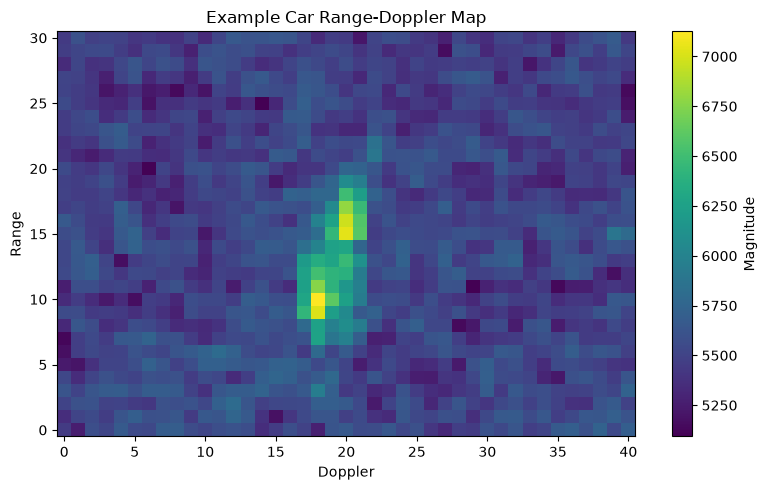

In [20]:
# Display an example car RD map.

plt.figure(figsize=(8, 5))

plt.imshow(
    all_car_data[0][0][0],
    aspect="auto",
    cmap="viridis",
    origin="lower",
)

plt.colorbar(label="Magnitude")
plt.title("Example Car Range-Doppler Map")
plt.xlabel("Doppler")
plt.ylabel("Range")

plt.tight_layout()
plt.show()

# RadarModel: CNN for Radar Object Classification

The model combines two types of information:

### 1. Range-Doppler map

The cropped RD map is processed using convolutional layers to learn spatial radar features.

### 2. Radar metadata

The following numerical radar features are provided directly to the classifier:

* RCS
* Speed/Doppler
* Range
* Azimuth

The CNN representation and the numerical features are concatenated before the fully connected classification layers.


In [21]:
import torch
import torch.nn as nn
import torch.optim as optim

# Number of output classes.
num_classes = 5


class RadarModel(nn.Module):

    def __init__(self):
        super().__init__()

        # First convolutional layer.
        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=4,
            kernel_size=3,
            padding="same",
        )

        # Spatial downsampling.
        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2,
        )

        # Second convolutional layer.
        self.conv2 = nn.Conv2d(
            in_channels=4,
            out_channels=8,
            kernel_size=3,
            padding="same",
        )

        # Dropout for regularization.
        self.dropout = nn.Dropout(0.6)

        # For an input of 31 x 41:
        #
        # 31 x 41
        #   -> pooling -> 15 x 20
        #   -> pooling -> 7 x 10
        #
        # 8 feature maps × 7 × 10 = 560 CNN features.
        #
        # Four additional scalar features are concatenated:
        # RCS, speed, range, azimuth.
        #
        # Total = 560 + 4 = 564.
        self.fc1 = nn.Linear(564, 32)

        # Final classification layer.
        self.fc3 = nn.Linear(32, num_classes)

    def forward(
        self,
        image,
        rcs,
        speed,
        range1,
        azimuth,
    ):

        # Extract spatial features from the RD map.
        x = torch.relu(self.conv1(image))
        x = self.pool(x)

        x = torch.relu(self.conv2(x))
        x = self.pool(x)

        x = self.dropout(x)

        # Flatten the CNN feature maps.
        x = x.view(x.size(0), -1)

        # Combine CNN features with radar metadata.
        x = torch.cat((rcs,speed,range1,azimuth,x,),dim=1,)

        # Fully connected classification layers.
        x = torch.relu(self.fc1(x))
        x = self.fc3(x)

        return x


# Create the model.
model = RadarModel()

print(model)

RadarModel(
  (conv1): Conv2d(1, 4, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(4, 8, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (dropout): Dropout(p=0.6, inplace=False)
  (fc1): Linear(in_features=564, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=5, bias=True)
)


In [22]:
# Convert the complete dataset to PyTorch tensors.
#
# Doing this before train_test_split means that the training and
# validation datasets are already tensors and no additional
# conversions are required later.

X_normalized_tensor = torch.from_numpy(X_normalized).float()

rcs_tensor = torch.tensor(RCS,dtype=torch.float32,).view(-1, 1)

speed_tensor = torch.tensor(Speed,dtype=torch.float32,).view(-1, 1)

range_tensor = torch.tensor(Range,dtype=torch.float32,).view(-1, 1)

azimuth_tensor = torch.tensor(Azm,dtype=torch.float32,).view(-1, 1)

y_tensor = torch.tensor(y,dtype=torch.long,)

In [23]:
from sklearn.model_selection import train_test_split

X_training, X_testing, y_training, y_testing, RCS_training, RCS_testing, Speed_training, \
Speed_testing, Range_training, Range_testing, Azimuth_training, Azimuth_testing, \
Sample_training, Sample_testing, Stamp_training, Stamp_testing, run_training, \
run_testing = train_test_split( X_normalized_tensor, y_tensor, rcs_tensor, speed_tensor, \
range_tensor, azimuth_tensor, Sample, Stamp, runs, train_size=0.80, random_state=42, \
stratify=y_tensor
)

print(f"Training samples:   {len(y_training):,}")
print(f"Validation samples: {len(y_testing):,}")

Training samples:   3,256
Validation samples: 814


In [24]:
# Check the number of samples from each class in the training set.
np.unique(
    y_training.numpy(),
    return_counts=True,
)

(array([0, 1, 2, 3, 4]), array([651, 652, 651, 651, 651]))

In [25]:
from torch.utils.data import DataLoader, TensorDataset

# This experiment is intentionally configured for CPU execution.
device = torch.device("cpu")

print(f"Using device: {device}")

model = model.to(device)

# Optimizer and classification loss.
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001,
)

criterion = nn.CrossEntropyLoss()

# Training parameters.
epochs = 130
batch_size = 32

# Training dataset.
train_data = TensorDataset(
    X_training,
    RCS_training,
    Speed_training,
    Range_training,
    Azimuth_training,
    y_training,
)

train_loader = DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=True,
)

# Validation dataset.
test_data = TensorDataset(
    X_testing,
    RCS_testing,
    Speed_testing,
    Range_testing,
    Azimuth_testing,
    y_testing,
)

val_loader = DataLoader(
    test_data,
    batch_size=batch_size,
    shuffle=False,
)

# Store training history.
train_losses = []
val_losses = []

for epoch in range(epochs):

    # ---------------------------------------------------------
    # Training
    # ---------------------------------------------------------

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for batch in train_loader:

        images, rcs, speed, range1, azimuth, labels = batch

        images = images.to(device)
        rcs = rcs.to(device)
        speed = speed.to(device)
        range1 = range1.to(device)
        azimuth = azimuth.to(device)
        labels = labels.to(device)

        # Clear gradients from the previous iteration.
        optimizer.zero_grad()

        # Forward pass.
        outputs = model(images,rcs,speed,range1,azimuth,)

        # Calculate classification loss.
        loss = criterion(outputs,labels,)

        # Backpropagation.
        loss.backward()

        # Update model parameters.
        optimizer.step()

        # Accumulate training statistics.
        running_loss += loss.item()

        predicted = torch.argmax(outputs,dim=1,)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = (running_loss / len(train_loader))

    train_accuracy = (100 * correct / total)

    train_losses.append(train_loss)

    # ---------------------------------------------------------
    # Validation
    # ---------------------------------------------------------

    model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for batch in val_loader:

            (val_images,val_rcs,val_speed,val_range1,val_azimuth,val_labels,) = batch

            val_outputs = model(val_images,val_rcs,val_speed,val_range1,val_azimuth,)

            val_loss += criterion(val_outputs,val_labels,).item()

            val_predicted = torch.argmax(val_outputs,dim=1,)

            val_total += val_labels.size(0)

            val_correct += (val_predicted == val_labels).sum().item()

    val_loss /= len(val_loader)

    val_accuracy = (100 * val_correct / val_total)

    val_losses.append(val_loss)

    print(
        f"Epoch [{epoch + 1}/{epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Accuracy: {val_accuracy:.2f}%"
    )

Using device: cpu
Epoch [1/130] | Train Loss: 1.3042 | Train Accuracy: 46.56% | Val Loss: 1.0797 | Val Accuracy: 60.81%
Epoch [2/130] | Train Loss: 1.0352 | Train Accuracy: 57.71% | Val Loss: 0.9425 | Val Accuracy: 64.37%
Epoch [3/130] | Train Loss: 0.9079 | Train Accuracy: 62.53% | Val Loss: 0.8276 | Val Accuracy: 65.60%
Epoch [4/130] | Train Loss: 0.8330 | Train Accuracy: 64.68% | Val Loss: 0.7869 | Val Accuracy: 68.92%
Epoch [5/130] | Train Loss: 0.7842 | Train Accuracy: 67.32% | Val Loss: 0.7357 | Val Accuracy: 68.92%
Epoch [6/130] | Train Loss: 0.7506 | Train Accuracy: 69.32% | Val Loss: 0.7027 | Val Accuracy: 72.85%
Epoch [7/130] | Train Loss: 0.7297 | Train Accuracy: 69.23% | Val Loss: 0.6835 | Val Accuracy: 74.45%
Epoch [8/130] | Train Loss: 0.6968 | Train Accuracy: 71.87% | Val Loss: 0.6735 | Val Accuracy: 73.71%
Epoch [9/130] | Train Loss: 0.6804 | Train Accuracy: 73.53% | Val Loss: 0.6235 | Val Accuracy: 76.29%
Epoch [10/130] | Train Loss: 0.6623 | Train Accuracy: 73.83% | V

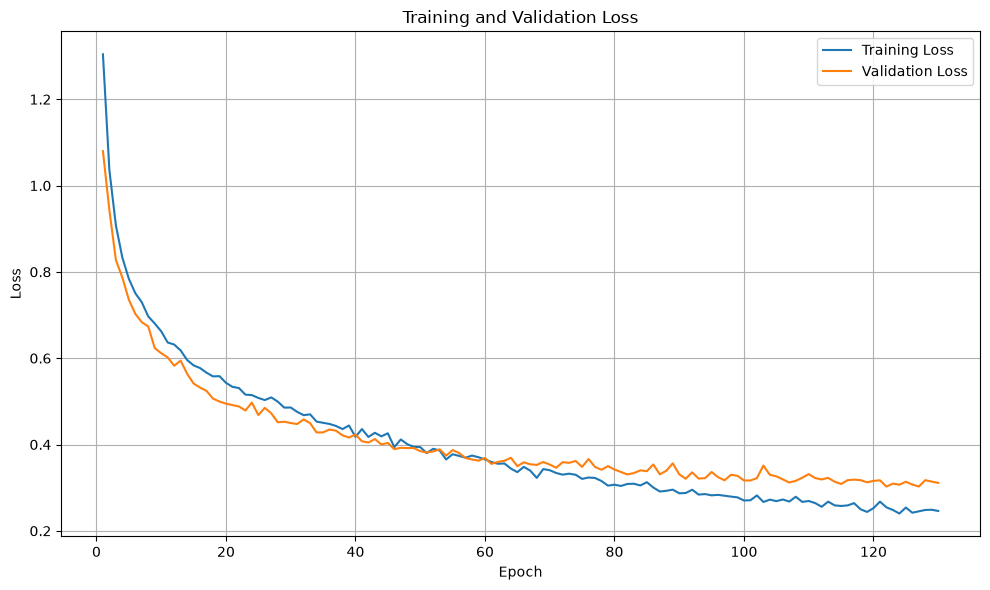

In [26]:
plt.figure(figsize=(10, 6))

plt.plot(range(1, epochs + 1),train_losses,label="Training Loss",)

plt.plot(range(1, epochs + 1),val_losses,label="Validation Loss",)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Permutation Feature Importance

This experiment investigates how strongly the trained model depends on each input.

For every feature:

1. The original model output is calculated.
2. One feature is randomly shuffled between samples.
3. The model output is calculated again.
4. The difference between the original and shuffled outputs is measured.

The features considered are:

* RD map
* RCS
* Speed
* Range
* Azimuth

A larger change indicates greater sensitivity of the model to that input under this particular permutation metric.


{'RD map': 0.20031072199344635, 'RCS': 0.017074214294552803, 'Speed': 0.008021565154194832, 'Range': 0.02494547888636589, 'Azimuth': 0.11276251077651978}


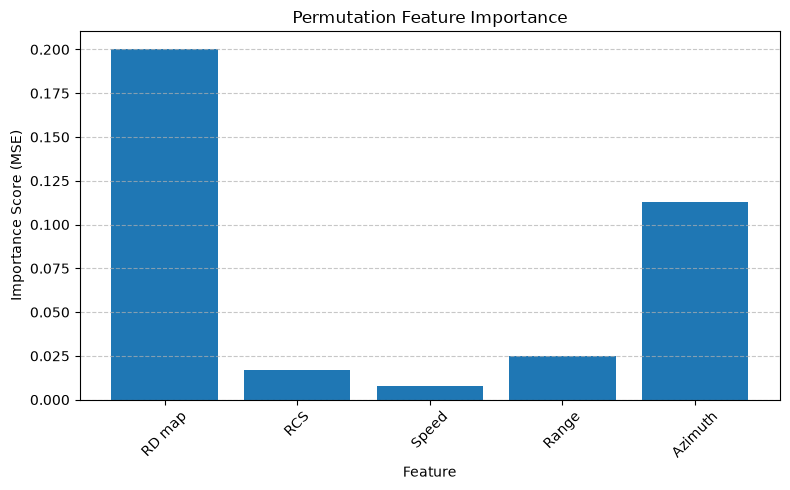

In [27]:
model.eval()

# Keep the model on CPU.
device = torch.device("cpu")
model.to(device)


def compute_output(*inputs):
    """
    Compute class probabilities from the trained model.
    """

    with torch.no_grad():

        logits = model(*inputs)

        return torch.softmax(logits,dim=1,)


# Original model inputs.
input_tensors = [X_training,RCS_training,Speed_training,Range_training,Azimuth_training,]

input_names = ["RD map","RCS","Speed","Range","Azimuth",]

# Model output without permutation.
original_output = compute_output(*input_tensors)

feature_importance = {}

for index, name in enumerate(input_names):

    # Randomly shuffle the selected feature across samples.
    shuffled_tensor = input_tensors[index][
        torch.randperm(input_tensors[index].size(0))
    ]

    # Replace only the selected input.
    shuffled_inputs = input_tensors.copy()
    shuffled_inputs[index] = shuffled_tensor

    # Calculate the output after permutation.
    shuffled_output = compute_output(
        *shuffled_inputs
    )

    # Measure the change in model output.
    importance = torch.mean(
        (
            original_output
            - shuffled_output
        ) ** 2
    ).item()

    feature_importance[name] = importance

print(feature_importance)
plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance.keys(),
    feature_importance.values(),
)

plt.xlabel("Feature")
plt.ylabel("Importance Score (MSE)")
plt.title("Permutation Feature Importance")
plt.xticks(rotation=45)

plt.grid(axis="y",linestyle="--",alpha=0.7,)

plt.tight_layout()
plt.show()

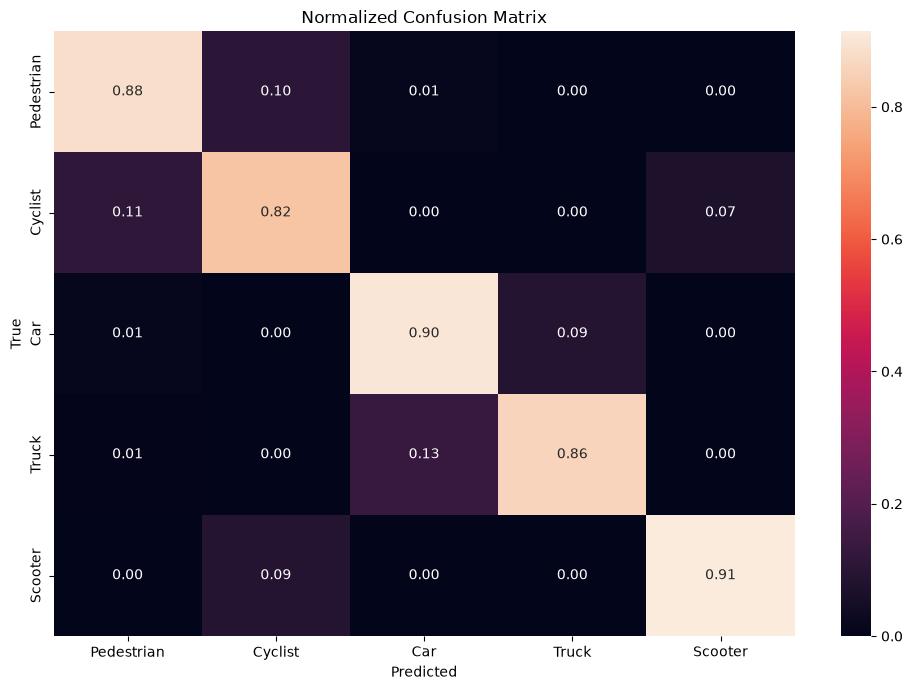

In [28]:
import seaborn as sns

from sklearn.metrics import confusion_matrix

# Human-readable class names.
classes = {
    0: "Pedestrian",
    1: "Cyclist",
    2: "Car",
    3: "Truck",
    4: "Scooter",
}

model.eval()

all_preds = []
all_labels = []
logs = []

with torch.no_grad():

    for batch in val_loader:

        (val_images,val_rcs,val_speed,val_range1, val_azimuth,val_labels,) = batch

        # Model prediction.
        val_outputs = model(val_images,val_rcs,val_speed,val_range1,val_azimuth,)

        # Convert logits to class probabilities.
        val_probabilities = torch.softmax(val_outputs,dim=1,)

        # Store probabilities and labels.
        logs.extend(val_probabilities.numpy())

        all_preds.extend( torch.argmax(val_probabilities,dim=1,).numpy())

        all_labels.extend(val_labels.numpy())

all_preds = np.asarray(all_preds)
all_labels = np.asarray(all_labels)
logs = np.asarray(logs)



# Calculate the confusion matrix.
cm = confusion_matrix(all_labels,all_preds,)

# Normalize each row so that each class is represented
# as a fraction of its true samples.
cmn = (cm.astype(float)/ cm.sum(axis=1)[:, np.newaxis])

plt.figure(figsize=(10, 7))

sns.heatmap(
    cmn,
    annot=True,
    fmt=".2f",
    xticklabels=list(classes.values()),
    yticklabels=list(classes.values()),
)

plt.ylabel("True")
plt.xlabel("Predicted")
plt.title("Normalized Confusion Matrix")

plt.tight_layout()
plt.show()

# Multiclass ROC Curve

The ROC curve evaluates the ability of the classifier to distinguish each class from all other classes.

A **one-vs-rest** approach is used:

* One class is treated as the positive class.
* All other classes are treated as the negative class.

The Area Under the Curve (AUC) summarizes the resulting ROC curve.


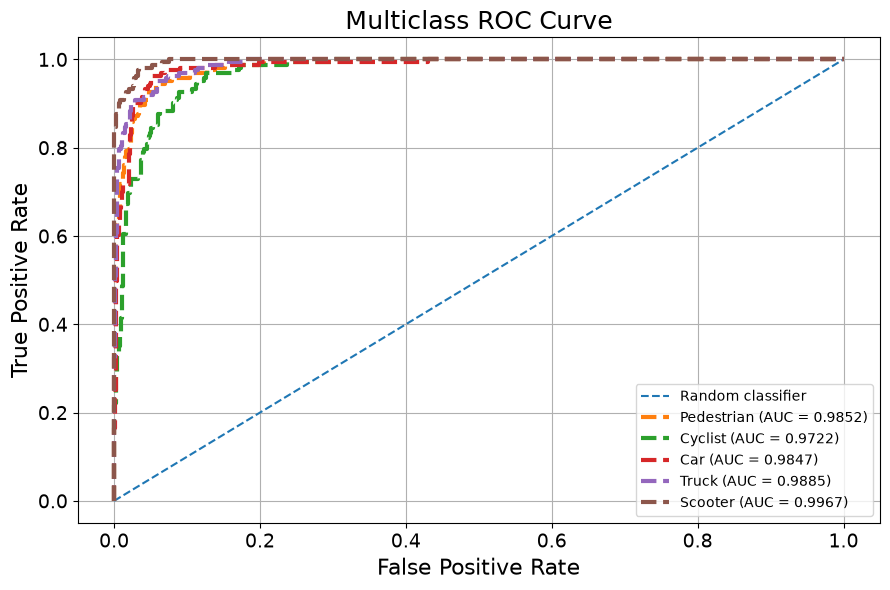

In [29]:
from sklearn.metrics import roc_curve, roc_auc_score

class_dict = {
    0: "Pedestrian",
    1: "Cyclist",
    2: "Car",
    3: "Truck",
    4: "Scooter",
}

fpr = {}
tpr = {}
thresh = {}
roc_auc = {}

# Calculate a one-vs-rest ROC curve for every class.
for i in range(num_classes):

    binary_labels = (all_labels == i ).astype(int)

    fpr[i], tpr[i], thresh[i] = roc_curve(binary_labels,logs[:, i],)

    roc_auc[i] = roc_auc_score(binary_labels,logs[:, i],)

# Plot all one-vs-rest ROC curves.

plt.figure(figsize=(9, 6))

# Random-classifier reference line.
plt.plot([0, 1],[0, 1],linestyle="--",label="Random classifier",)

for i in range(num_classes):

    class_name = class_dict.get(i,f"Class {i}",)

    plt.plot(fpr[i],tpr[i],linestyle="--",linewidth=3,label=(f"{class_name} "
            f"(AUC = {roc_auc[i]:.4f})"
        ),
    )

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlabel("False Positive Rate",fontsize=16,)

plt.ylabel("True Positive Rate",fontsize=16,)

plt.title("Multiclass ROC Curve",fontsize=18,)

plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

# Keras Implementation

The following section implements the same general architecture using Keras/TensorFlow.

The model has five inputs:

1. Range-Doppler map
2. RCS
3. Speed
4. Range
5. Azimuth

The RD map is processed by the CNN branch, while the four numerical radar features are concatenated with the extracted CNN representation before classification.

A 5-fold cross-validation procedure is used to evaluate the model.


In [30]:
from sklearn.model_selection import KFold

from tensorflow.keras import Input, Model
from tensorflow.keras.layers import (
    Concatenate,
    Conv2D,
    Dense,
    Dropout,
    Activation,
    Flatten,
    MaxPooling2D,
)
from tensorflow.keras import optimizers

In [31]:
# Five-fold cross-validation:


kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

cvscores = []
history = []

# Indices used for cross-validation.
ID_Inp = np.arange(len(X_normalized_keras))

ID_Out = np.arange(len(y))

for fold, (train_idx, test_idx) in enumerate(
    kfold.split(ID_Inp),
    start=1,
):

    print(
        f"\n========== Fold {fold}/5 =========="
    )

    # ---------------------------------------------------------
    # Define model inputs
    # ---------------------------------------------------------

    image = Input(shape=X_normalized_keras.shape[1:],name="RD_map",)

    rcs_keras = Input(shape=(1,),name="RCS",)

    speed_keras = Input(shape=(1,),name="Speed",)

    range_keras = Input(shape=(1,),name="Range",)

    azimuth_keras = Input(shape=(1,), name="Azimuth",)

    # ---------------------------------------------------------
    # CNN branch
    # ---------------------------------------------------------

    x = Conv2D(filters=4,kernel_size=(3, 3),padding="same",)(image)

    x = Activation("relu")(x)

    x = MaxPooling2D(pool_size=(2, 2))(x)

    x = Conv2D(filters=8,kernel_size=(3, 3),padding="same",)(x)

    x = Activation("relu")(x)

    x = MaxPooling2D(pool_size=(2, 2))(x)

    x = Dropout(0.6)(x)

    x = Flatten()(x)

    # ---------------------------------------------------------
    # Feature fusion
    # ---------------------------------------------------------

    concat_layer = Concatenate()([rcs_keras,speed_keras,range_keras,azimuth_keras,x,])

    # Fully connected classifier.
    output = Dense(32,activation="relu",)(concat_layer)

    output = Dense(5,activation="softmax",)(output)

    # Create the complete multi-input model.
    model200 = Model(
        inputs=[image,rcs_keras,speed_keras,range_keras,azimuth_keras,],outputs=output,)

    # ---------------------------------------------------------
    # Compile
    # ---------------------------------------------------------

    model200.compile(
        loss="sparse_categorical_crossentropy",
        optimizer=optimizers.Adam(
            learning_rate=0.001
        ),
        metrics=["accuracy"],
    )

    # ---------------------------------------------------------
    # Train
    # ---------------------------------------------------------

    fold_history = model200.fit(
        [
            X_normalized_keras[train_idx],
            RCS[train_idx],
            Speed[train_idx],
            Range[train_idx],
            Azm[train_idx],
        ],
        y[train_idx],

        epochs=150,
        batch_size=32,
        verbose=0,

        validation_data=(
            [
                X_normalized_keras[test_idx],
                RCS[test_idx],
                Speed[test_idx],
                Range[test_idx],
                Azm[test_idx],
            ],
            y[test_idx],
        ),
    )

    history.append(
        fold_history
    )

    # ---------------------------------------------------------
    # Evaluate
    # ---------------------------------------------------------

    scores = model200.evaluate(
        [
            X_normalized_keras[test_idx],
            RCS[test_idx],
            Speed[test_idx],
            Range[test_idx],
            Azm[test_idx],
        ],
        y[test_idx],
        verbose=0,
    )

    print(f"Validation accuracy: "f"{scores[1] * 100:.2f}%")

    print(f"Validation loss: "f"{scores[0]:.4f}")

    cvscores.append(scores[1] * 100)

print(
    f"\nCross-validation accuracy: "
    f"{np.mean(cvscores):.2f}% "
    f"(+/- {np.std(cvscores):.2f}%)"
)


========== Fold 1/5 ==========
Validation accuracy: 88.70%
Validation loss: 0.3285

========== Fold 2/5 ==========
Validation accuracy: 88.33%
Validation loss: 0.2852

========== Fold 3/5 ==========
Validation accuracy: 86.49%
Validation loss: 0.3188

========== Fold 4/5 ==========
Validation accuracy: 87.59%
Validation loss: 0.3204

========== Fold 5/5 ==========
Validation accuracy: 88.33%
Validation loss: 0.3137

Cross-validation accuracy: 87.89% (+/- 0.79%)


## Export the model to ONNX

In [ ]:
# Export the trained PyTorch model to ONNX.

file_name = "radar53.onnx"

model.eval()

# Use one training sample to define the model inputs.
example_inputs = (
    X_training[:1],
    RCS_training[:1],
    Speed_training[:1],
    Range_training[:1],
    Azimuth_training[:1],
)

torch.onnx.export(
    model,
    example_inputs,
    file_name,

    input_names=[
        "Cropped_RD_map",
        "rcs",
        "speed",
        "range",
        "azimuth",
    ],

    output_names=[
        "output",
    ],

    dynamic_axes={
        "Cropped_RD_map": {0: "batch_size"},
        "rcs": {0: "batch_size"},
        "speed": {0: "batch_size"},
        "range": {0: "batch_size"},
        "azimuth": {0: "batch_size"},
        "output": {0: "batch_size"},
    },

    opset_version=11,
)

print(
    f"ONNX model exported successfully: {file_name}"
)

## Test the ONNX model

In [ ]:
import onnxruntime as ort

# Load the ONNX model using CPU execution.
session = ort.InferenceSession(
    file_name,
    providers=["CPUExecutionProvider"],
)

print(
    "ONNX Runtime providers:",
    session.get_providers(),
)

print(
    "Model output:",
    session.get_outputs()[0].name,
)

# Create test inputs with batch size 1.

batch_size_1 = {
    "Cropped_RD_map": np.random.randn(1, 1, 31, 41).astype(np.float32),

    "rcs": np.random.randn(1, 1).astype(np.float32),

    "speed": np.random.randn(1, 1).astype(np.float32),

    "range": np.random.randn(1, 1).astype(np.float32),

    "azimuth": np.random.randn(1, 1).astype(np.float32),
}


# Create test inputs with batch size 10.

batch_size_10 = {
    "Cropped_RD_map": np.random.randn(10, 1, 31, 41).astype(np.float32),

    "rcs": np.random.randn(10, 1).astype(np.float32),

    "speed": np.random.randn(10, 1).astype(np.float32),

    "range": np.random.randn(10, 1).astype(np.float32),

    "azimuth": np.random.randn(10, 1).astype(np.float32),
}

## # Run ONNX inference.

In [ ]:
# Run ONNX inference.

output_1 = session.run(None,batch_size_1,)[0]

output_10 = session.run(None,batch_size_10,)[0]

print(f"Output shape, batch size 1: "f"{output_1.shape}")

print(f"Output shape, batch size 10: "f"{output_10.shape}")


# ONNX outputs are logits.
# Convert them into probabilities using softmax.

logits = torch.from_numpy(output_10)

probabilities = torch.softmax(logits,dim=1,)

# Select the class with the highest probability.
predicted_labels = torch.argmax(probabilities,dim=1,)

print("Predicted labels:",predicted_labels.numpy(),)